<a href="https://colab.research.google.com/github/jethrocsau/mimic-multimodal-discordance/blob/main/modality_eda/ecg/ecg_hubert_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECG modality EDA — HuBERT embeddings (aligned with CXR notebook)



| | CXR notebook | this notebook |
|---|---|---|
| manifest `file_role` | `cxr_image_jpg` | `ecg_signal` |
| one record per (level, stay) | frontal first, then latest in baseline | latest in baseline |
| embeddings | CheXFound / MedSigLIP (`.npz`) | HuBERT-ECG 768-d (`ve_hubert_768.csv`) |

Run top to bottom. The first run scans the 12 GB embedding CSV (20–40 min) and caches the cohort rows to Drive; later runs load the cache in seconds.


## Setup

In [1]:
!pip -q install umap-learn

import os, re, time, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from google.colab import auth, drive
from google.cloud import bigquery
warnings.filterwarnings("ignore", category=FutureWarning)

# ---- settings ----
PROJECT   = "your GCP project"   # your GCP project: runs the queries
DATA_PROJ = "ace-apex-508114-n9"               # Jethro's project: holds the cohort tables (read only)
ECG_ROLE  = "ecg_signal"                       # ECG row type in x_file_manifest (ecg_header is the same records)
EMB_PATH  = "/content/drive/MyDrive/ECG_VE_Takeshi/ve_hubert_768.csv"
OUT_DIR   = "/content/drive/MyDrive/capstone_ecg"
CACHE     = f"{OUT_DIR}/ecg_hubert_levels.parquet"

if not os.path.exists("/content/drive"):
    drive.mount("/content/drive")
auth.authenticate_user()
client = bigquery.Client(project=PROJECT)
os.makedirs(OUT_DIR, exist_ok=True)

Mounted at /content/drive


## Helper Functions

In [2]:
# BigQuery: baseline ECGs per cohort-level stay, with label and demographics (same query as CXR, ECG rows)
def fetch_bigquery_manifest(bq_client):
    """
    One row per (cohort level, stay, ECG record) in the baseline window,
    for stays with all 5 modalities. Each level uses its own index stay.
    """
    print("Fetching cohort data and baseline ECGs from BigQuery...")
    query = f"""
        SELECT
          a.level_id, a.stay_id, a.subject_id, a.died_1y, a.age, a.sex,
          CASE
            WHEN adm.race LIKE 'WHITE%' THEN 'White'
            WHEN adm.race LIKE 'BLACK%' THEN 'Black'
            WHEN adm.race LIKE 'HISPANIC%' OR adm.race LIKE 'SOUTH AMERICAN%' THEN 'Hispanic/Latino'
            WHEN adm.race LIKE 'ASIAN%' THEN 'Asian'
            WHEN adm.race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') OR adm.race IS NULL THEN 'Unknown'
            ELSE 'Other'
          END AS race_group,
          CASE
            WHEN a.age < 65 THEN '18-64'
            WHEN a.age < 75 THEN '65-74'
            WHEN a.age < 85 THEN '75-84'
            ELSE '>=85'
          END AS age_group,
          m.record_id, m.study_id, m.hours_from_icu_admit
        FROM `{DATA_PROJ}.phase0.x_file_manifest` m
        INNER JOIN `{DATA_PROJ}.phase0.analysis_dataset` a
            ON a.stay_id = m.stay_id
        LEFT JOIN `physionet-data.mimiciv_3_1_hosp.admissions` adm
            ON adm.hadm_id = a.hadm_id
        WHERE m.file_role = '{ECG_ROLE}'
          AND m.phase = 'baseline'
          AND a.has_all5
          AND a.level_id IN ('L1', 'L2', 'L3')
    """
    manifest_df = bq_client.query(query).to_dataframe()

    # ECG key = MIMIC-IV-ECG study_id. Use the study_id column if filled, else the trailing number in record_id
    # (handles "40689238", "files/p1000/p10000032/s40689238/40689238" and ".../40689238.dat").
    from_record = manifest_df["record_id"].astype(str).str.strip().str.extract(r"(\d+)(?:\.\w+)?$")[0]
    from_study = pd.to_numeric(manifest_df["study_id"], errors="coerce").astype("Int64").astype(str)
    manifest_df["record_id_str"] = from_study.where(manifest_df["study_id"].notna(), from_record)

    print(f"Loaded {manifest_df.shape[0]:,} ECG rows "
          f"({manifest_df.groupby('level_id').stay_id.nunique().to_dict()} stays per level)")
    print("example record_id:", manifest_df["record_id"].head(3).tolist(),
          "| study_id:", manifest_df["study_id"].head(3).tolist(),
          "| key used:", manifest_df["record_id_str"].head(3).tolist())
    return manifest_df


# ECG embedding loader: scans the 12 GB CSV once for the needed study_ids, then caches them
def load_ecg_embeddings(file_path, keep_ids, cache_path=CACHE, chunksize=50_000):
    """
    Returns a DataFrame with one row per ECG, keyed by record_id_str (= study_id),
    plus the list of embedding columns. Rows with any NaN embedding value are dropped.
    """
    keep_ids = set(map(str, keep_ids))
    if os.path.exists(cache_path):
        emb_df = pd.read_parquet(cache_path)
        missing = keep_ids - set(emb_df["record_id_str"]) - set(np.load(cache_path + ".notfound.npy", allow_pickle=True)
                                                               if os.path.exists(cache_path + ".notfound.npy") else [])
        if not missing:
            print(f"Loaded cached embeddings: {cache_path}")
        else:
            print(f"Cache is missing {len(missing):,} needed ECGs; rescanning the CSV")
            emb_df = None
    else:
        emb_df = None

    if emb_df is None:
        print(f"Scanning {file_path} (12 GB, takes a while)...")
        parts, n_read, t0 = [], 0, time.time()
        for chunk in pd.read_csv(file_path, chunksize=chunksize):
            sid = chunk["filename"].astype(str).str.extract(r"(\d+)(?:\.\w+)?$")[0]
            hit = sid.isin(keep_ids)
            if hit.any():
                sub = chunk.loc[hit].drop(columns="filename").astype("float32")
                sub.insert(0, "record_id_str", sid[hit].values)
                parts.append(sub)
            n_read += len(chunk)
            print(f"  read {n_read:,} rows | matched {sum(len(p) for p in parts):,} | {time.time() - t0:.0f}s", end="\r")
        emb_df = pd.concat(parts, ignore_index=True).drop_duplicates("record_id_str")
        emb_df.to_parquet(cache_path)
        np.save(cache_path + ".notfound.npy", np.array(sorted(keep_ids - set(emb_df["record_id_str"]))))
        print(f"\nCached {len(emb_df):,} embeddings to {cache_path}")

    col_names = [c for c in emb_df.columns if c != "record_id_str"]
    n_nan = emb_df[col_names].isna().any(axis=1).sum()
    if n_nan:
        print(f"Warning: dropping {n_nan:,} ECGs with NaN embedding values")
        emb_df = emb_df.dropna(subset=col_names)
    print(f"Successfully loaded {emb_df.shape[0]:,} embeddings with {len(col_names)} dims")
    return emb_df, col_names

## Load data

In [3]:
# Fetch cohort manifest (ECG records + labels + demographics)
ecg_manifest_df = fetch_bigquery_manifest(client)

# Load ECG embeddings for those records
ecg_df, embedding_cols = load_ecg_embeddings(EMB_PATH, ecg_manifest_df["record_id_str"].dropna().unique())

# Join on study_id
raw_merged_df = pd.merge(ecg_manifest_df, ecg_df, on="record_id_str", how="inner")
print(f"Matched {raw_merged_df.shape[0]:,} of {ecg_manifest_df.shape[0]:,} ECG rows to an embedding")

# One ECG per (level, stay): the latest in the baseline window (CXR uses frontal first, then latest)
final_data_df = (raw_merged_df
                 .sort_values(["level_id", "stay_id", "hours_from_icu_admit"],
                              ascending=[True, True, False])
                 .drop_duplicates(subset=["level_id", "stay_id"])
                 .copy())
final_data_df["outcome"] = final_data_df["died_1y"].map({True: "Died", False: "Survived"})

# Stays lost because their ECG has no embedding
coverage = pd.DataFrame({
    "stays_all5_with_ecg": ecg_manifest_df.groupby("level_id").stay_id.nunique(),
    "stays_with_embedding": final_data_df.groupby("level_id").stay_id.nunique(),
})
coverage["missing"] = coverage.iloc[:, 0] - coverage.iloc[:, 1]
print(coverage)
print(f"final_data_df: {final_data_df.shape[0]:,} rows = one per (level, stay); "
      f"filter by level_id before modelling")

Fetching cohort data and baseline ECGs from BigQuery...
Loaded 14,028 ECG rows ({'L1': 997, 'L2': 1489, 'L3': 2323} stays per level)
example record_id: ['40013096', '40778825', '40929408'] | study_id: [40013096, 40778825, 40929408] | key used: ['40013096', '40778825', '40929408']
Scanning /content/drive/MyDrive/ECG_VE_Takeshi/ve_hubert_768.csv (12 GB, takes a while)...

Cached 6,713 embeddings to /content/drive/MyDrive/capstone_ecg/ecg_hubert_levels.parquet
Successfully loaded 6,549 embeddings with 768 dims
Matched 13,678 of 14,028 ECG rows to an embedding
          stays_all5_with_ecg  stays_with_embedding  missing
level_id                                                    
L1                        997                   995        2
L2                       1489                  1486        3
L3                       2323                  2319        4
final_data_df: 4,800 rows = one per (level, stay); filter by level_id before modelling


**Check:** `stays_all5_with_ecg` should equal the CXR notebook's stay counts (L1 997, L2 1,489, L3 2,323): same patients, different modality. `missing` should be close to 0. If `Matched` is 0, look at the printed `example record_id` / `key used` line.

## Exploring Demographics

=== Patient Counts per Cohort ===
Cohort L1: 995 patients, 354 died within 1y (35.6%)
Cohort L2: 1,486 patients, 489 died within 1y (32.9%)
Cohort L3: 2,319 patients, 584 died within 1y (25.2%)


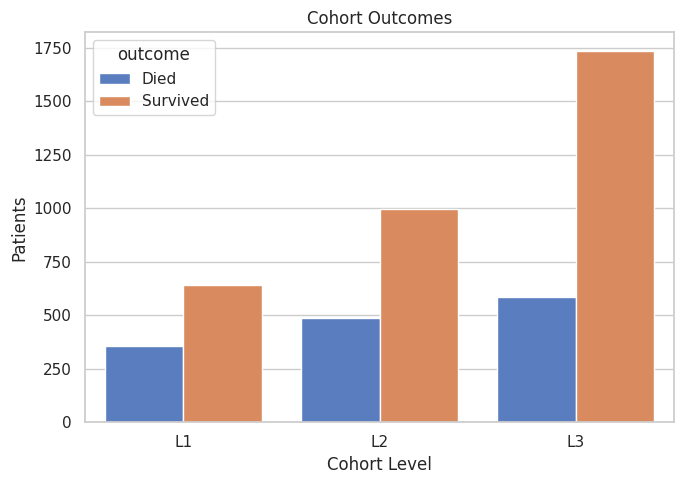

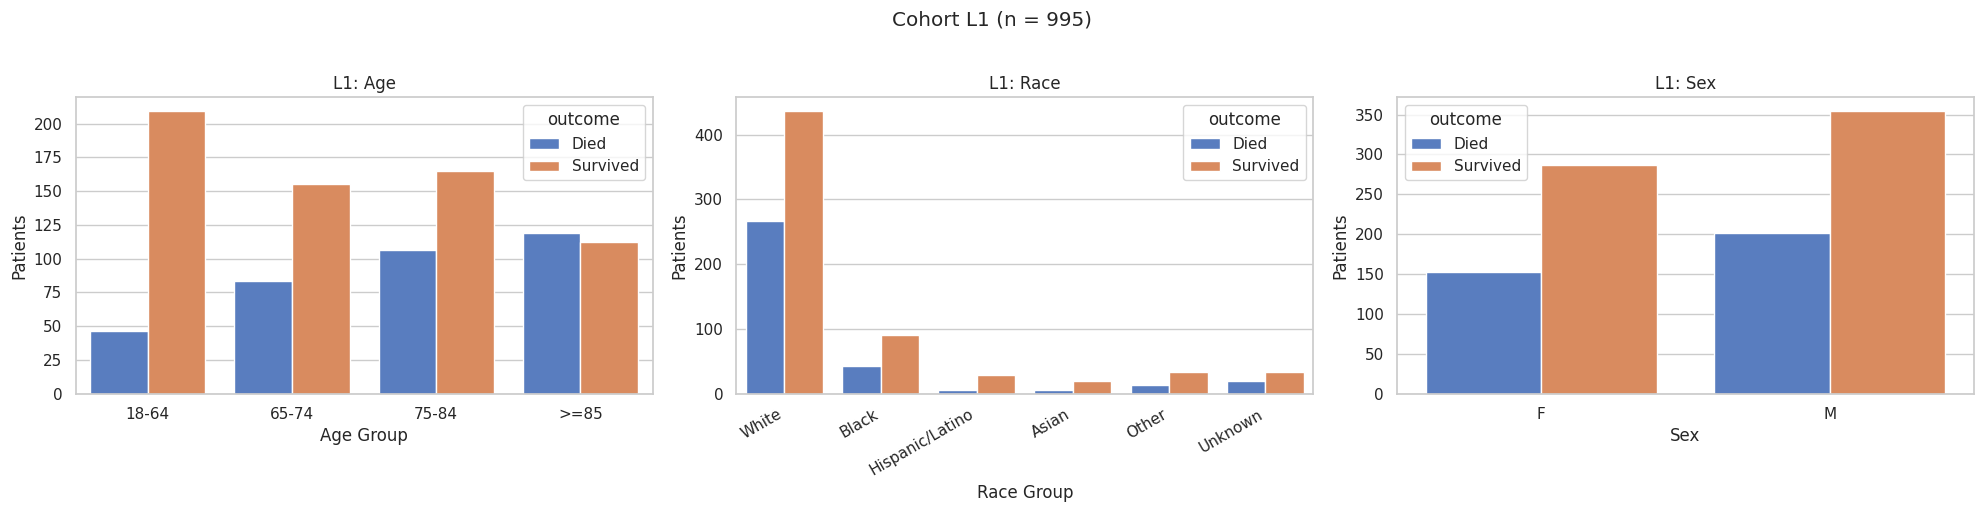

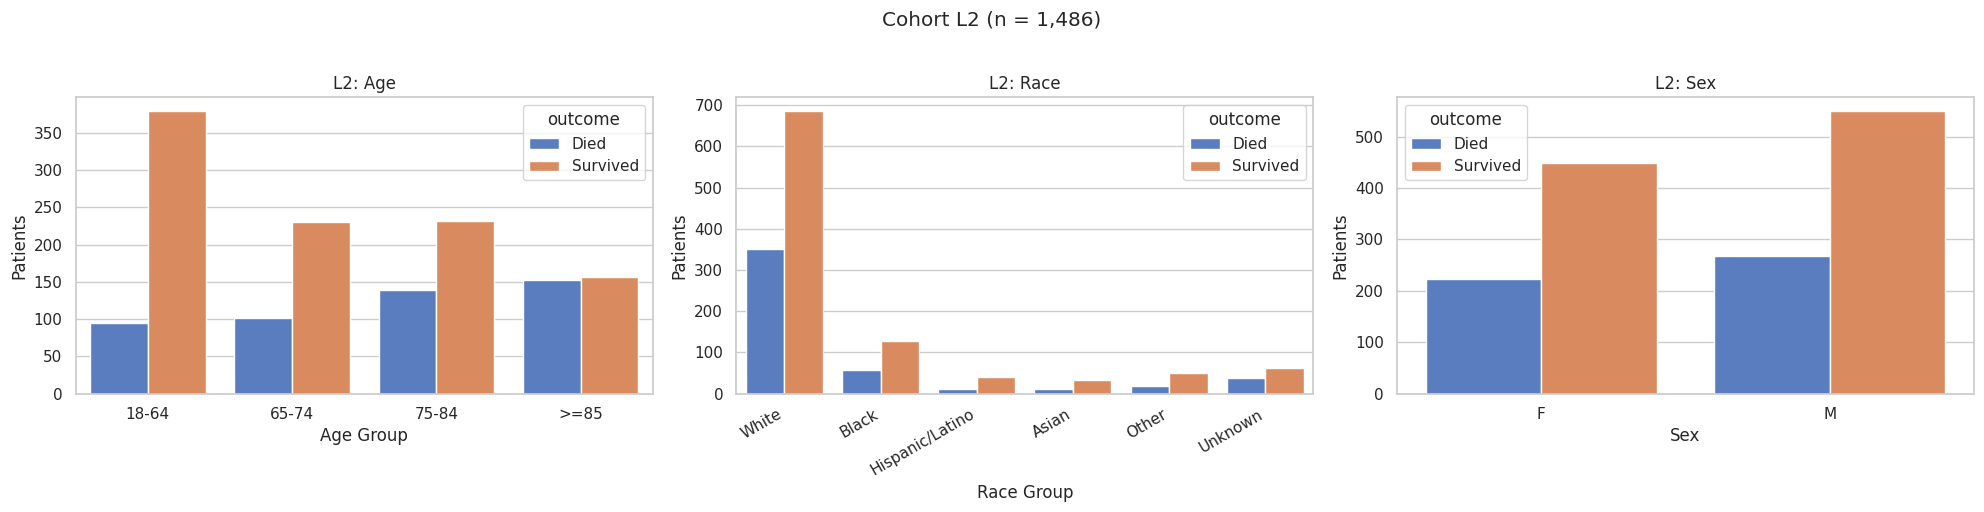

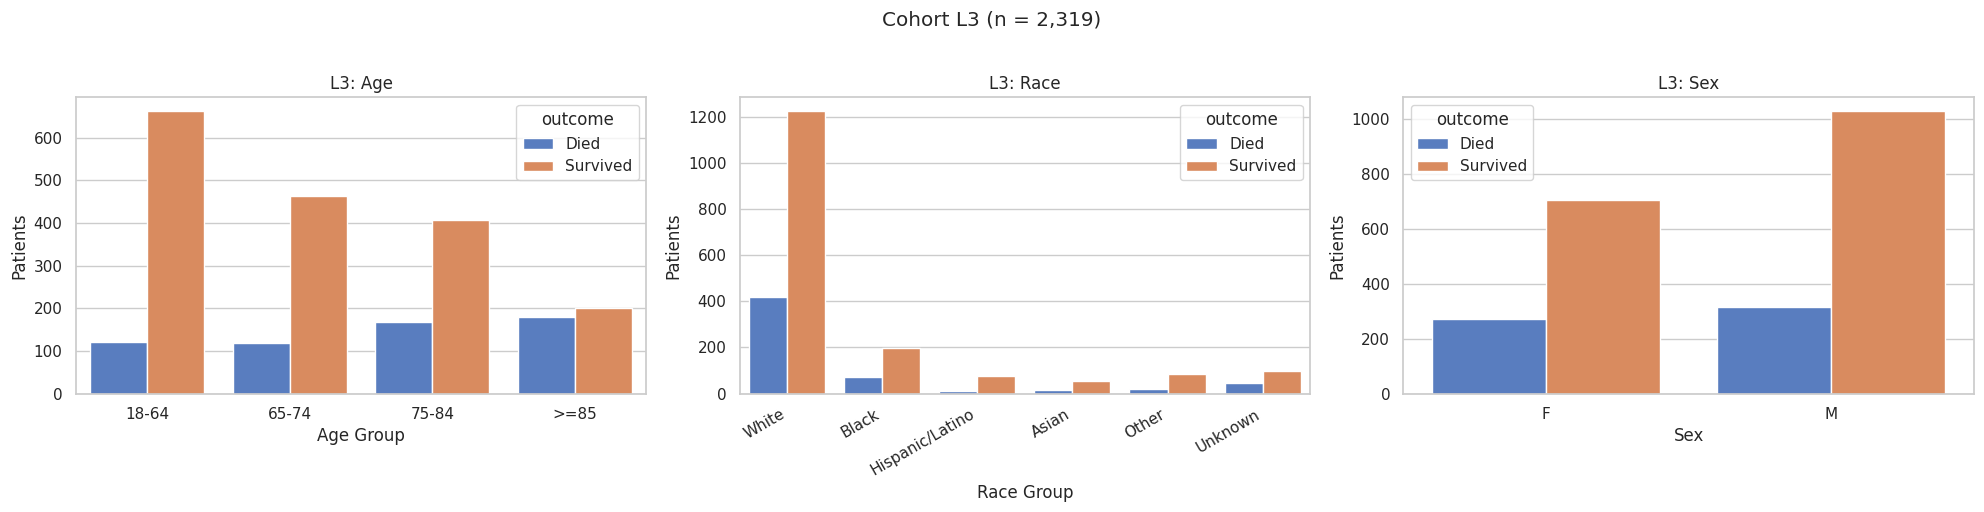

In [4]:
dem_patient_df = final_data_df

print("=== Patient Counts per Cohort ===")
for lvl in ['L1', 'L2', 'L3']:
    d = dem_patient_df[dem_patient_df['level_id'] == lvl]
    print(f"Cohort {lvl}: {d['subject_id'].nunique():,} patients, "
          f"{d['died_1y'].sum():,} died within 1y ({100 * d['died_1y'].mean():.1f}%)")

sns.set_theme(style="whitegrid")
race_order = ['White', 'Black', 'Hispanic/Latino', 'Asian', 'Other', 'Unknown']
age_order = ['18-64', '65-74', '75-84', '>=85']

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=dem_patient_df, x='level_id', hue='outcome', ax=ax,
              palette='muted', order=['L1', 'L2', 'L3'])
ax.set(title='Cohort Outcomes', xlabel='Cohort Level', ylabel='Patients')
plt.tight_layout()
plt.show()

for lvl in ['L1', 'L2', 'L3']:
    d = dem_patient_df[dem_patient_df['level_id'] == lvl]
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.countplot(data=d, x='age_group', hue='outcome', ax=axes[0], palette='muted', order=age_order)
    axes[0].set(title=f'{lvl}: Age', xlabel='Age Group', ylabel='Patients')

    sns.countplot(data=d, x='race_group', hue='outcome', ax=axes[1], palette='muted', order=race_order)
    axes[1].set(title=f'{lvl}: Race', xlabel='Race Group', ylabel='Patients')
    axes[1].set_xticks(range(len(race_order)))
    axes[1].set_xticklabels(race_order, rotation=30, ha='right')

    sns.countplot(data=d, x='sex', hue='outcome', ax=axes[2], palette='muted', order=['F', 'M'])
    axes[2].set(title=f'{lvl}: Sex', xlabel='Sex', ylabel='Patients')

    fig.suptitle(f'Cohort {lvl} (n = {d.subject_id.nunique():,})', y=1.02)
    plt.tight_layout()
    plt.show()

## Embedding Visualization

In [5]:
def plot_umap_cohorts_faceted(final_df, embedding_cols, levels=['L1', 'L2', 'L3'], random_state=88):
    """
    2D UMAP of ECG embeddings per cohort level (one ECG per patient),
    coloured by 1-year outcome, sex, age group and race group.
    """
    orders = {
        'outcome':    ['Survived', 'Died'],
        'sex':        ['F', 'M'],
        'age_group':  ['18-64', '65-74', '75-84', '>=85'],
        'race_group': ['White', 'Black', 'Hispanic/Latino', 'Asian', 'Other', 'Unknown'],
    }
    outcome_palette = {'Survived': '#1E88E5', 'Died': '#D81B60'}
    color_vars = [
        ('outcome',    '1-Year Outcome', outcome_palette),
        ('sex',        'Sex',            'Set1'),
        ('age_group',  'Age Group',      'viridis'),
        ('race_group', 'Race Group',     'tab10'),
    ]

    for level in levels:
        cohort_subset = final_df[final_df['level_id'] == level].dropna(subset=embedding_cols).copy()
        if cohort_subset.empty:
            print(f"Cohort {level} has no matched data. Skipping.")
            continue
        assert cohort_subset['subject_id'].is_unique, \
            f"{level}: more than one row per patient; pass final_data_df, not raw_merged_df"

        print(f"\nRunning UMAP for Cohort {level} (N={len(cohort_subset):,} patients)...")
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=random_state)
        xy = reducer.fit_transform(cohort_subset[embedding_cols].values)
        cohort_subset['umap_x'], cohort_subset['umap_y'] = xy[:, 0], xy[:, 1]

        fig, axes = plt.subplots(1, 4, figsize=(28, 6.5))
        for ax, (col_var, title, palette) in zip(axes, color_vars):
            sns.scatterplot(data=cohort_subset, x='umap_x', y='umap_y', hue=col_var,
                            hue_order=[v for v in orders[col_var] if v in set(cohort_subset[col_var])],
                            ax=ax, alpha=0.7, s=12, palette=palette)
            ax.set(title=f"{level} - {title}", xlabel="UMAP Dim 1", ylabel="UMAP Dim 2")
            ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left')
            ax.grid(True, alpha=0.3)

        plt.suptitle(f"Cohort {level} ECG embeddings (N={len(cohort_subset):,} patients)", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/ecg_umap_{level}.png", dpi=150, bbox_inches="tight")
        plt.show()


Running UMAP for Cohort L1 (N=995 patients)...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


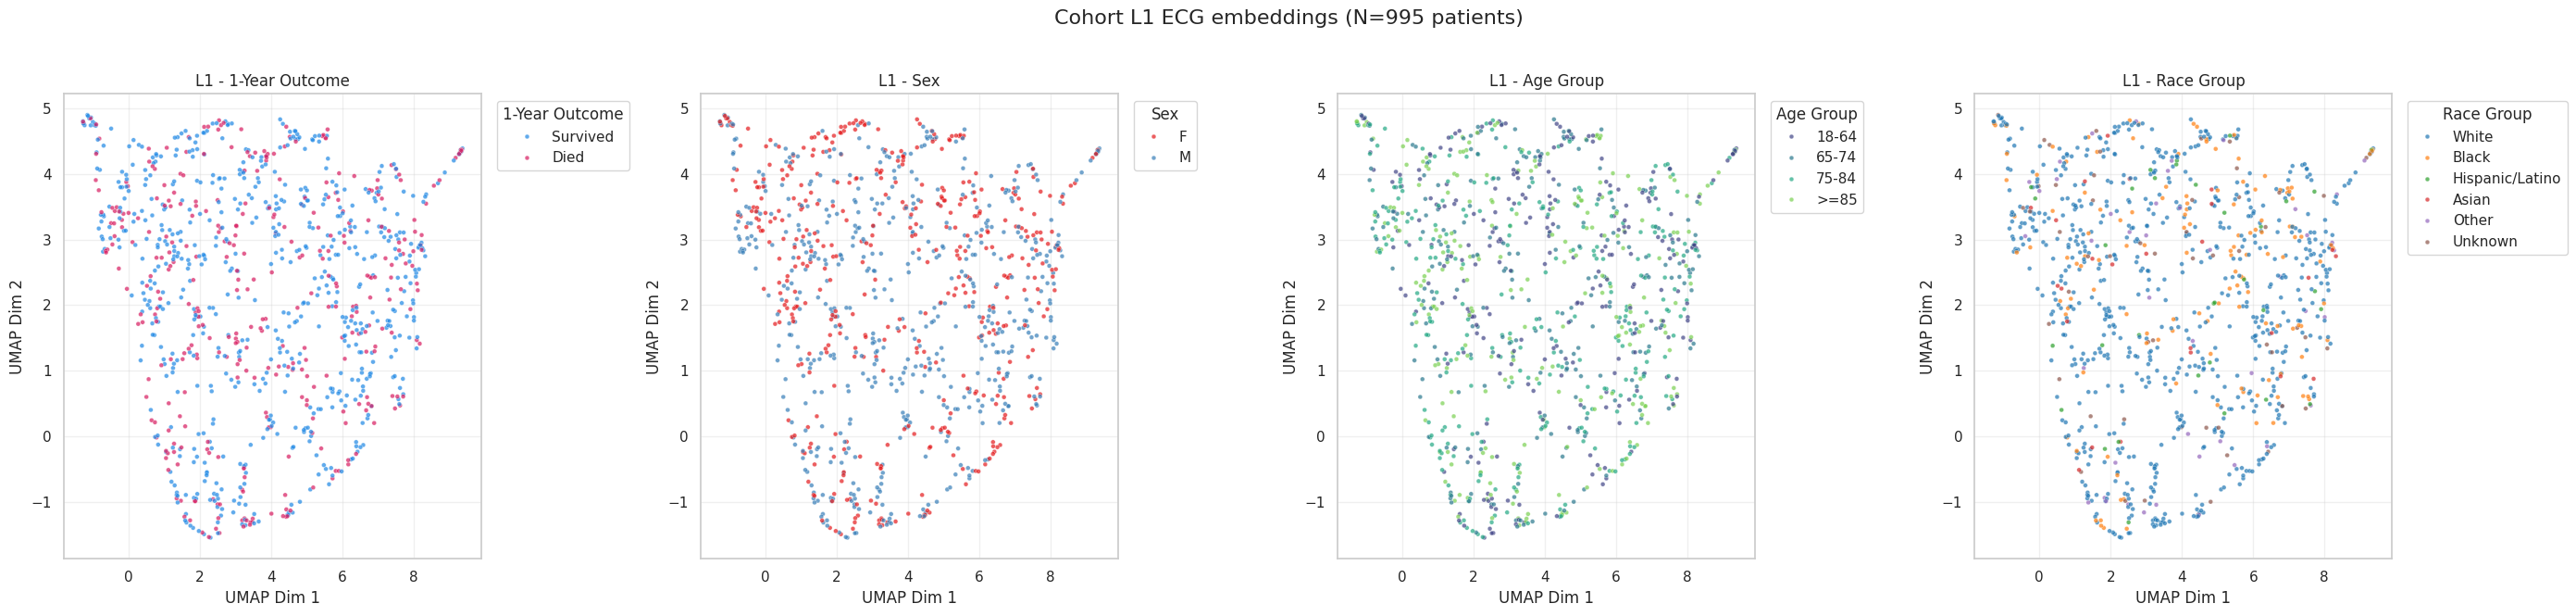


Running UMAP for Cohort L2 (N=1,486 patients)...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


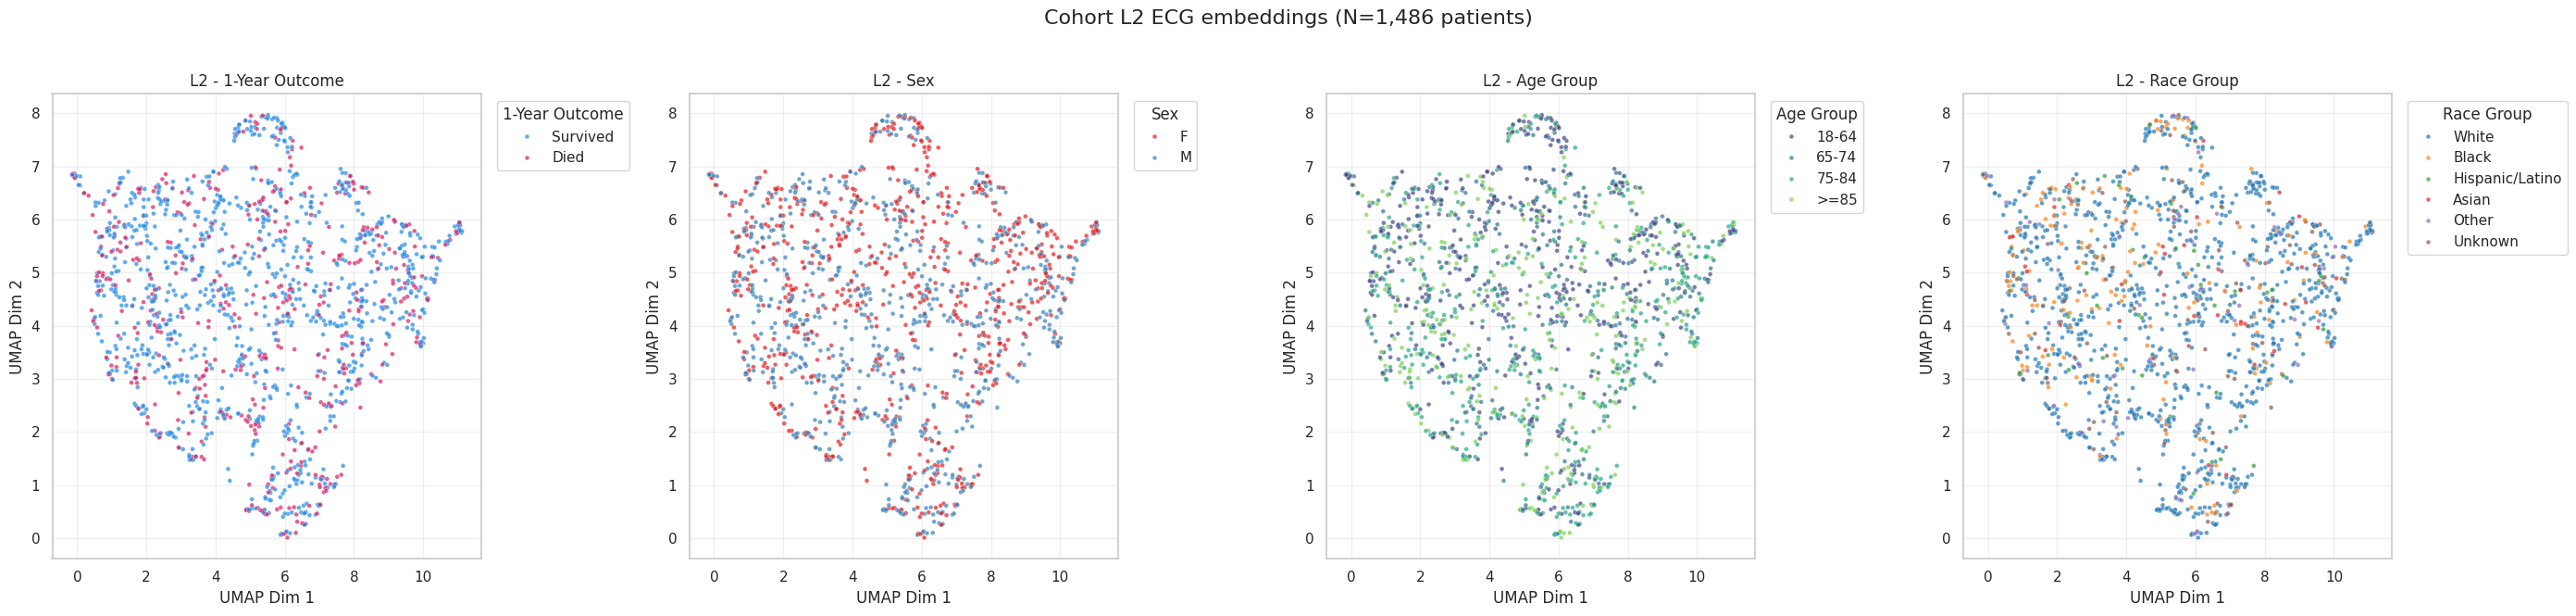


Running UMAP for Cohort L3 (N=2,319 patients)...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


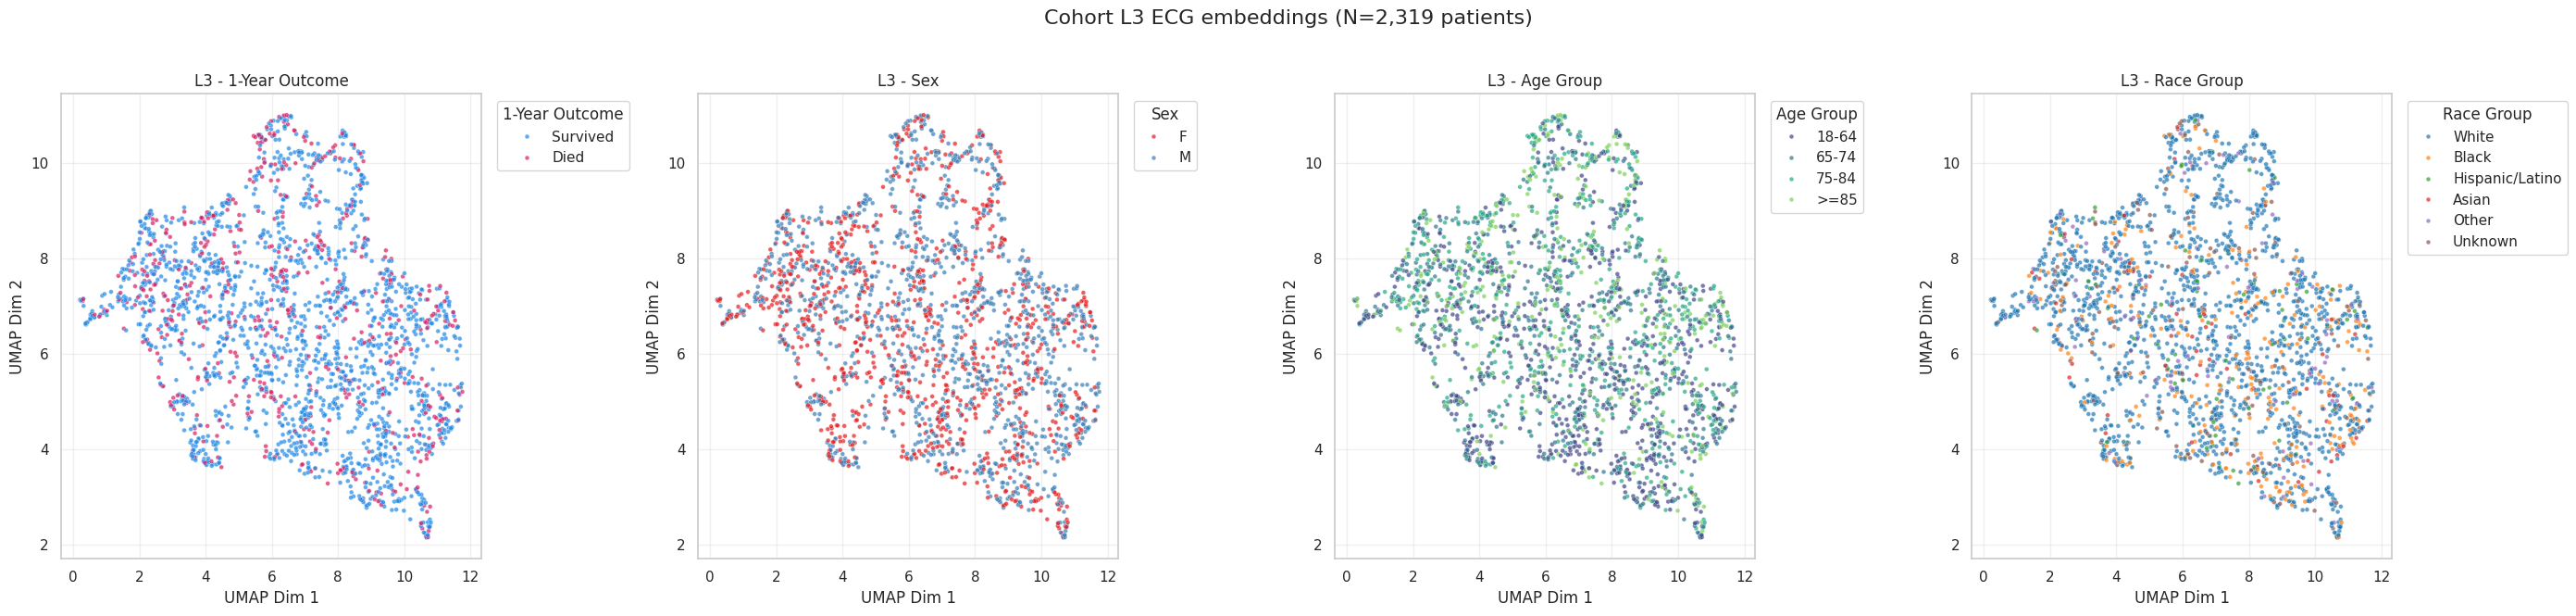

In [6]:
plot_umap_cohorts_faceted(final_data_df, embedding_cols)

## Unimodal probe
Functions copied unchanged from the CXR notebook.

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score,
                             f1_score, confusion_matrix)

# 1. Dataset splitting
def split_cohort_data(df, embedding_cols, target_col='died_1y', test_size=0.1, val_size=0.1, random_state=88):
    """
    One cohort level in, stratified 80/10/10 patient-level split out.
    Returns standardized embeddings (X) and demographics (D: age, male) for each split.
    Scalers are fit on the training split only.
    """
    model_df = df.dropna(subset=embedding_cols + ['age', 'sex']).copy()
    assert model_df['subject_id'].is_unique, "filter to one level_id first (one row per patient)"

    X = model_df[embedding_cols].values
    D = np.column_stack([model_df['age'].astype(float).values,
                         (model_df['sex'] == 'M').astype(int).values])
    y = model_df[target_col].astype(int).values

    idx = np.arange(len(y))
    idx_tv, idx_te = train_test_split(idx, test_size=test_size, stratify=y, random_state=random_state)
    idx_tr, idx_va = train_test_split(idx_tv, test_size=val_size / (1 - test_size),
                                      stratify=y[idx_tv], random_state=random_state)

    xs = StandardScaler().fit(X[idx_tr])
    ds = StandardScaler().fit(D[idx_tr])
    Xs, Ds = xs.transform(X), ds.transform(D)

    print(f"N={len(y):,} ({y.sum():,} died, {100 * y.mean():.1f}%) | "
          f"train {len(idx_tr):,} / val {len(idx_va):,} / test {len(idx_te):,} "
          f"({y[idx_te].sum()} deaths in test)")
    return (Xs[idx_tr], Xs[idx_va], Xs[idx_te],
            Ds[idx_tr], Ds[idx_va], Ds[idx_te],
            y[idx_tr], y[idx_va], y[idx_te])


# 2. Logistic regression, L2 strength C tuned on validation AUROC
def train_logistic_classifier(X_train, y_train, X_val=None, y_val=None, random_state=88):
    c_candidates = [0.001, 0.01, 0.1, 0.5, 1.0, 2.5, 10]

    def fit(c):
        return LogisticRegression(penalty='l2', solver='lbfgs', max_iter=2000, C=c,
                                  class_weight='balanced', random_state=random_state).fit(X_train, y_train)

    if X_val is None or y_val is None:
        return fit(1.0)

    best_clf, best_c, best_auc = None, None, -1.0
    for c in c_candidates:
        clf = fit(c)
        auc = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
        if auc > best_auc:
            best_clf, best_c, best_auc = clf, c, auc
    print(f"  LR: best C = {best_c} (val AUROC {best_auc:.4f})")
    return best_clf


# 3. Simple neural network
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


def train_single_nn(X_train, y_train, X_val, y_val, hidden_dim, epochs=50, batch_size=64, lr=0.001, random_state=88):
    torch.manual_seed(random_state)
    model = SimpleNN(input_dim=X_train.shape[1], hidden_dim=hidden_dim, dropout_rate=0.3)

    loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train).unsqueeze(1)),
                        batch_size=batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(random_state))
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    X_val_t, y_val_t = torch.FloatTensor(X_val), torch.FloatTensor(y_val).unsqueeze(1)

    best_val_loss, best_weights = float('inf'), None
    for _ in range(epochs):
        model.train()
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    return model, best_val_loss


def train_nn_classifier(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.001, random_state=88):
    input_dim = X_train.shape[1]
    best_model, best_loss, best_dim = None, float('inf'), None
    for hidden_dim in [max(input_dim // 2, 1), max(input_dim // 4, 1), max(input_dim // 8, 1), max(input_dim // 16, 1)]:
        model, val_loss = train_single_nn(X_train, y_train, X_val, y_val, hidden_dim,
                                          epochs, batch_size, lr, random_state)
        if val_loss < best_loss:
            best_model, best_loss, best_dim = model, val_loss, hidden_dim
    print(f"  NN: best hidden size = {best_dim} (val loss {best_loss:.4f})")
    return best_model


def nn_predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.FloatTensor(X)).numpy().ravel()


# 4. Threshold and confidence intervals
def youden_threshold(y_val, p_val):
    """Threshold maximizing sensitivity + specificity - 1 on the validation set."""
    fpr, tpr, thr = roc_curve(y_val, p_val)
    return float(thr[np.argmax(tpr - fpr)])


def bootstrap_ci(y_true, y_prob, metric=roc_auc_score, n=1000, seed=88):
    rng = np.random.default_rng(seed)
    stats = []
    for _ in range(n):
        i = rng.integers(0, len(y_true), len(y_true))
        if y_true[i].min() == y_true[i].max():
            continue
        stats.append(metric(y_true[i], y_prob[i]))
    return np.percentile(stats, [2.5, 97.5])


# 5. Evaluation and plots
def evaluate_and_plot(y_true, y_pred_prob, title_suffix, threshold=0.5, plot=True):
    y_pred = (y_pred_prob >= threshold).astype(int)
    auroc = roc_auc_score(y_true, y_pred_prob)
    lo, hi = bootstrap_ci(y_true, y_pred_prob)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'AUROC': round(auroc, 4),
        'AUROC 95% CI': f"{lo:.3f}-{hi:.3f}",
        'AUPRC': round(average_precision_score(y_true, y_pred_prob), 4),
        'F1': round(f1_score(y_true, y_pred, zero_division=0), 4),
        'PPV (Precision)': round(tp / (tp + fp), 4) if (tp + fp) else 0.0,
        'NPV': round(tn / (tn + fn), 4) if (tn + fn) else 0.0,
        'Sensitivity (Recall)': round(tp / (tp + fn), 4) if (tp + fn) else 0.0,
        'Specificity': round(tn / (tn + fp), 4) if (tn + fp) else 0.0,
        'Threshold': round(threshold, 4),
    }

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
        axes[0].plot(fpr, tpr, color='darkorange', lw=2,
                     label=f'AUC = {auroc:.3f} (95% CI {lo:.3f}-{hi:.3f})')
        axes[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
        axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title=f'ROC Curve - {title_suffix}')
        axes[0].legend(loc='lower right')
        axes[0].grid(True, alpha=0.3)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                    xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'])
        axes[1].set(xlabel='Predicted Label', ylabel='True Label',
                    title=f'Confusion Matrix - {title_suffix} (threshold {threshold:.3f})')
        plt.tight_layout()
        plt.show()

    return metrics

## Cohort-by-Cohort Evaluation and Side-by-Side Comparison


PROCESSING COHORT: L1
N=995 (354 died, 35.6%) | train 795 / val 100 / test 100 (36 deaths in test)
  LR: best C = 0.1 (val AUROC 0.5117)


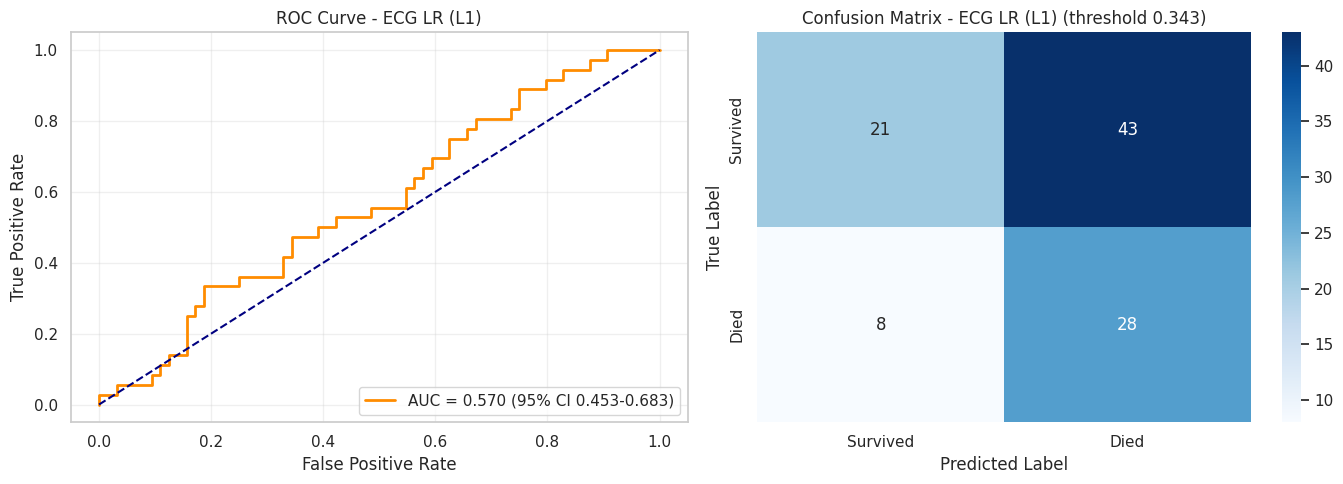

  NN: best hidden size = 48 (val loss 0.6893)


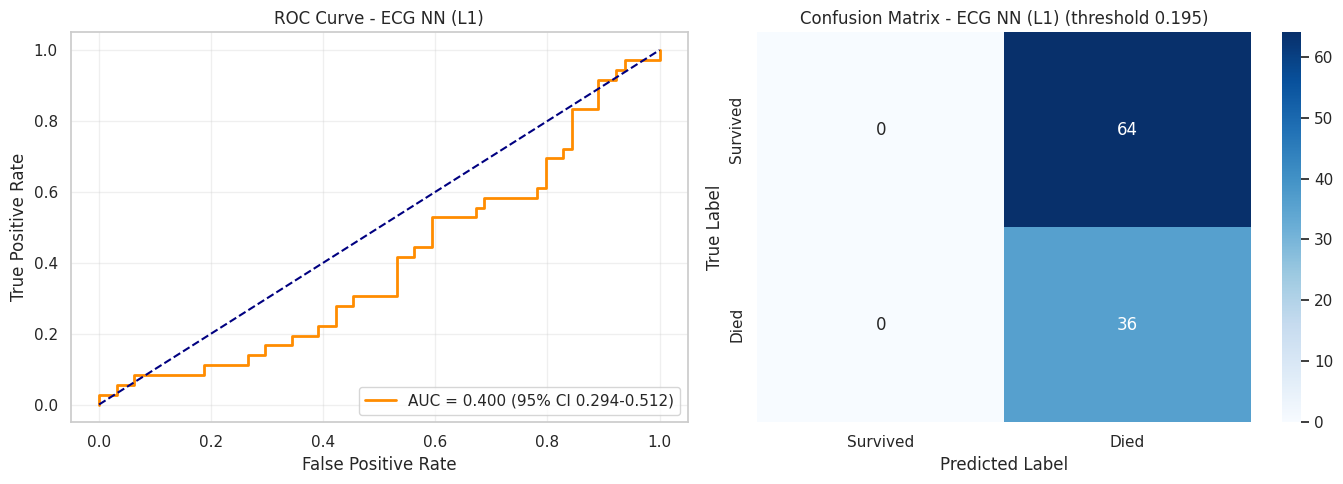

  LR: best C = 0.01 (val AUROC 0.6636)


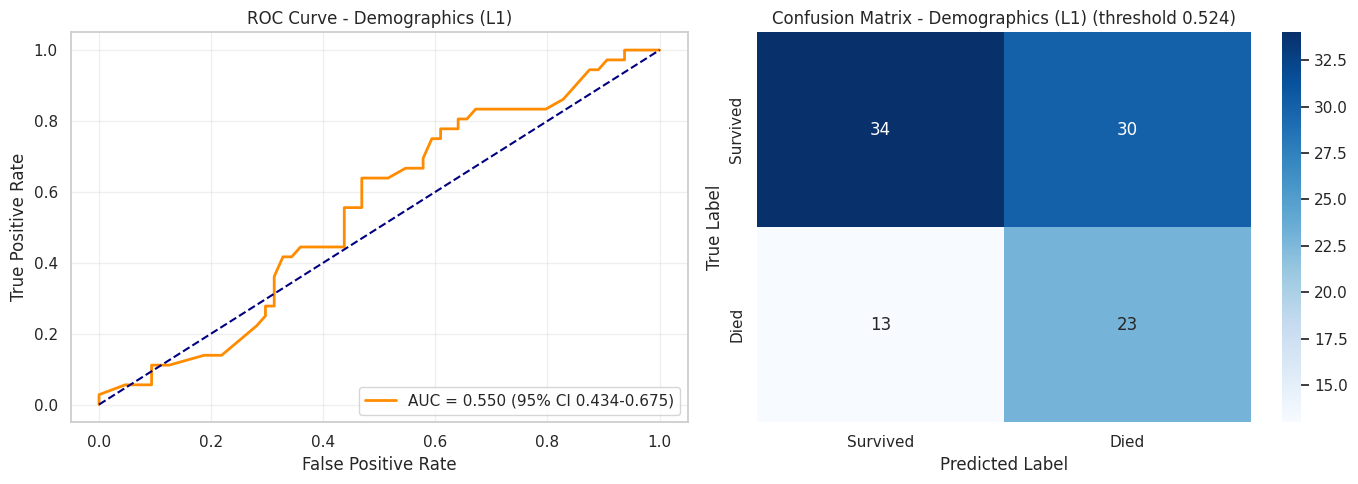


PROCESSING COHORT: L2
N=1,486 (489 died, 32.9%) | train 1,188 / val 149 / test 149 (49 deaths in test)
  LR: best C = 10 (val AUROC 0.6288)


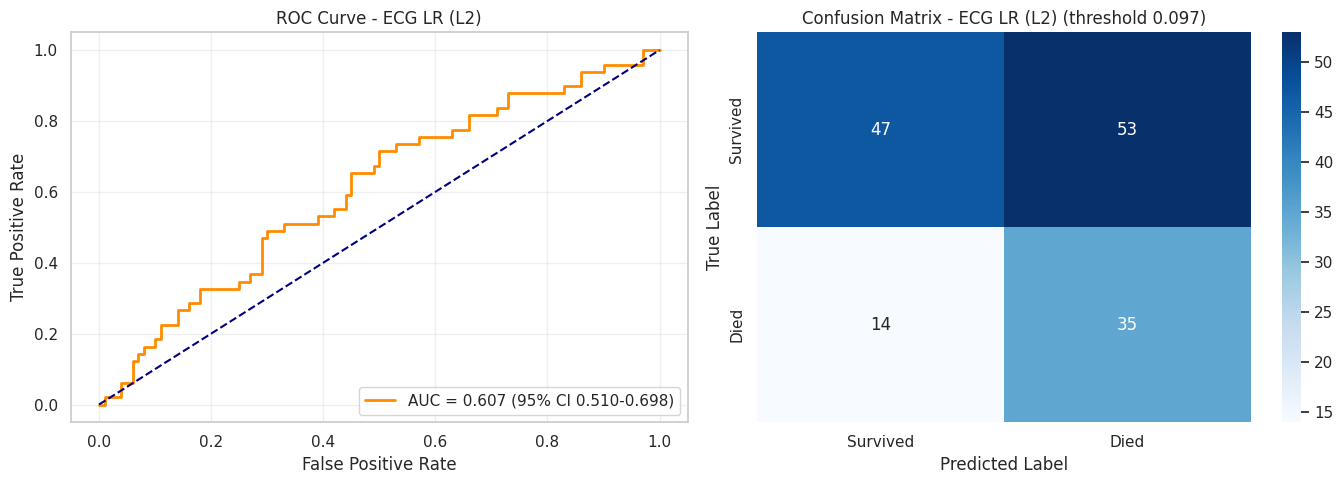

  NN: best hidden size = 48 (val loss 0.6049)


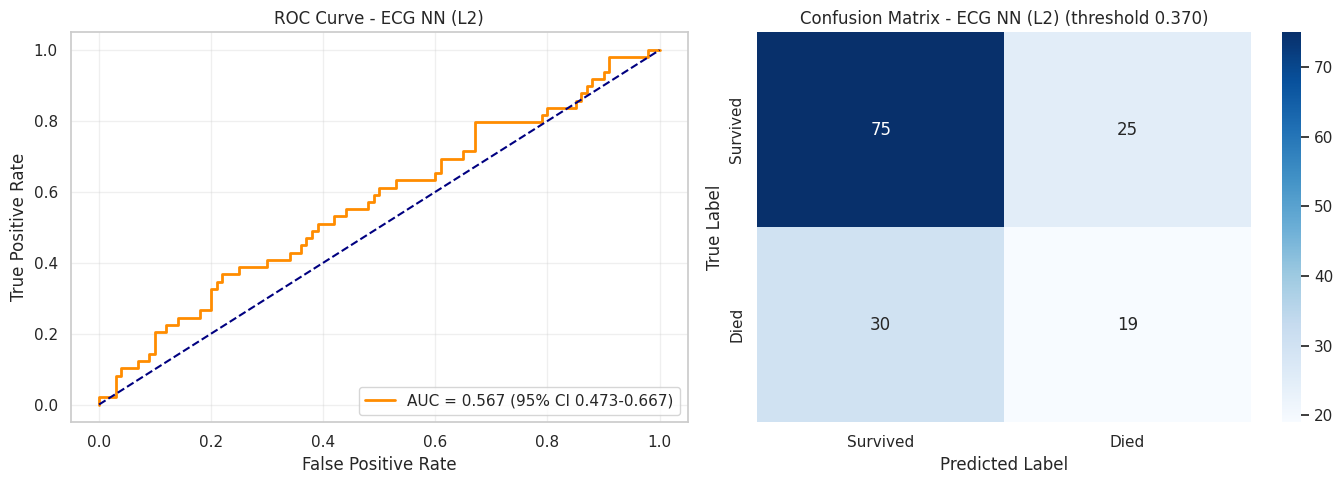

  LR: best C = 0.1 (val AUROC 0.6161)


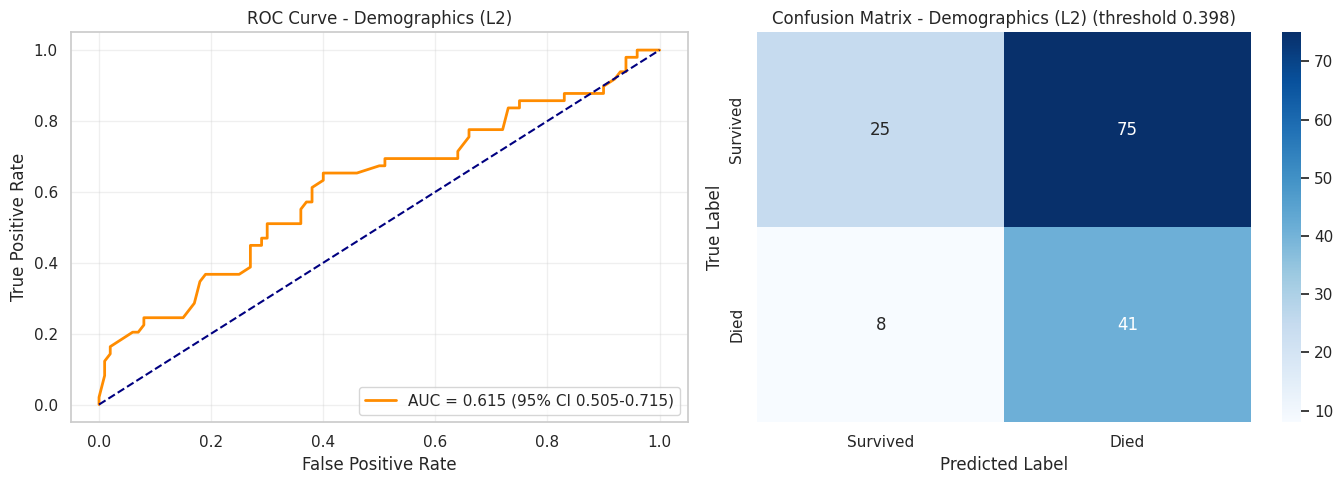


PROCESSING COHORT: L3
N=2,319 (584 died, 25.2%) | train 1,855 / val 232 / test 232 (58 deaths in test)
  LR: best C = 10 (val AUROC 0.6462)


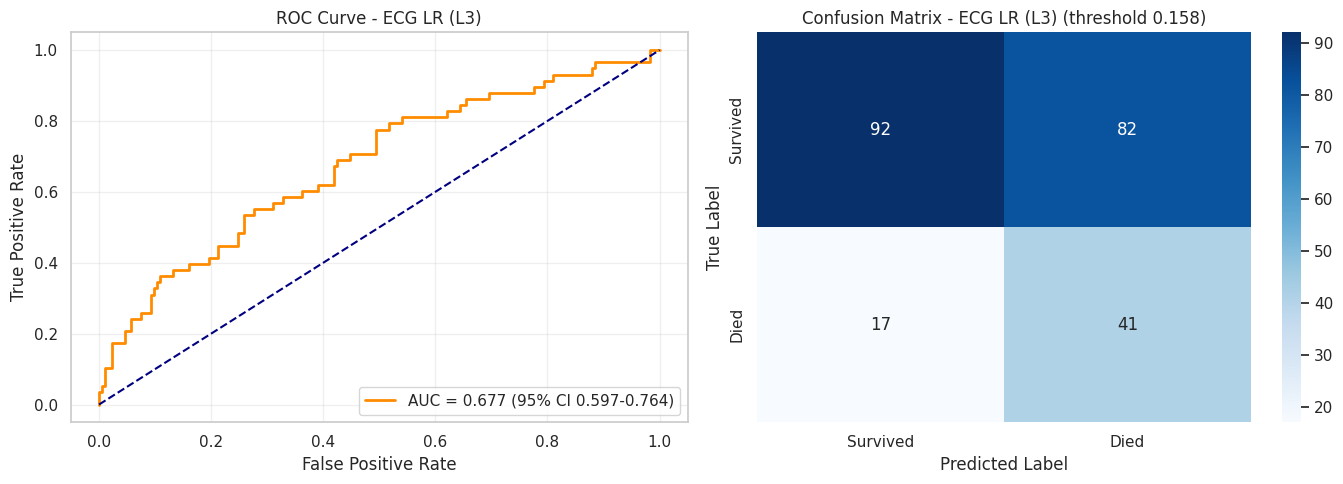

  NN: best hidden size = 48 (val loss 0.5508)


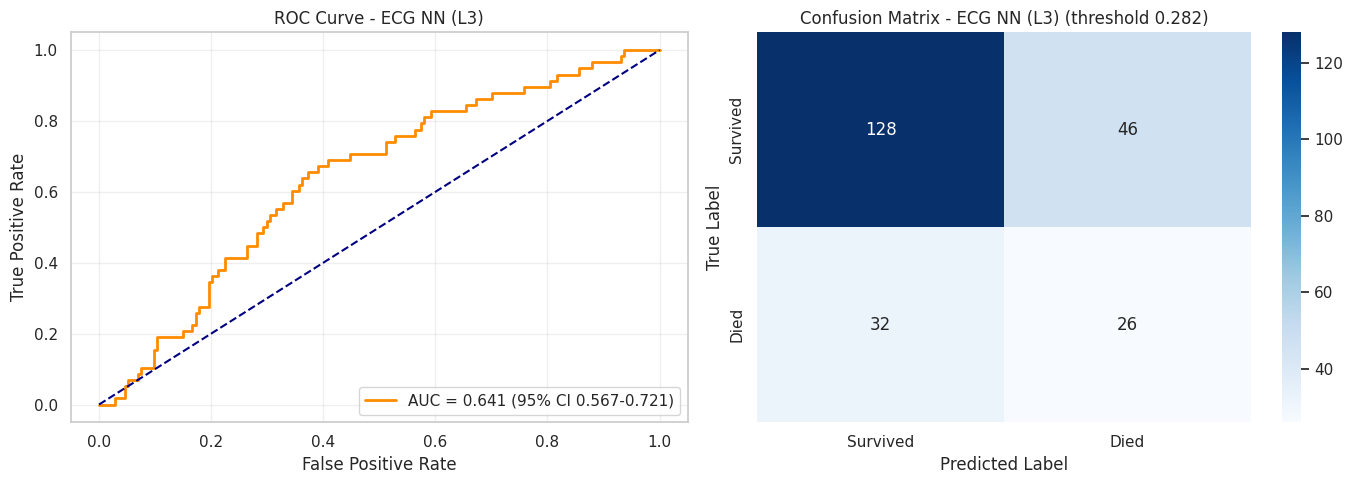

  LR: best C = 0.01 (val AUROC 0.6484)


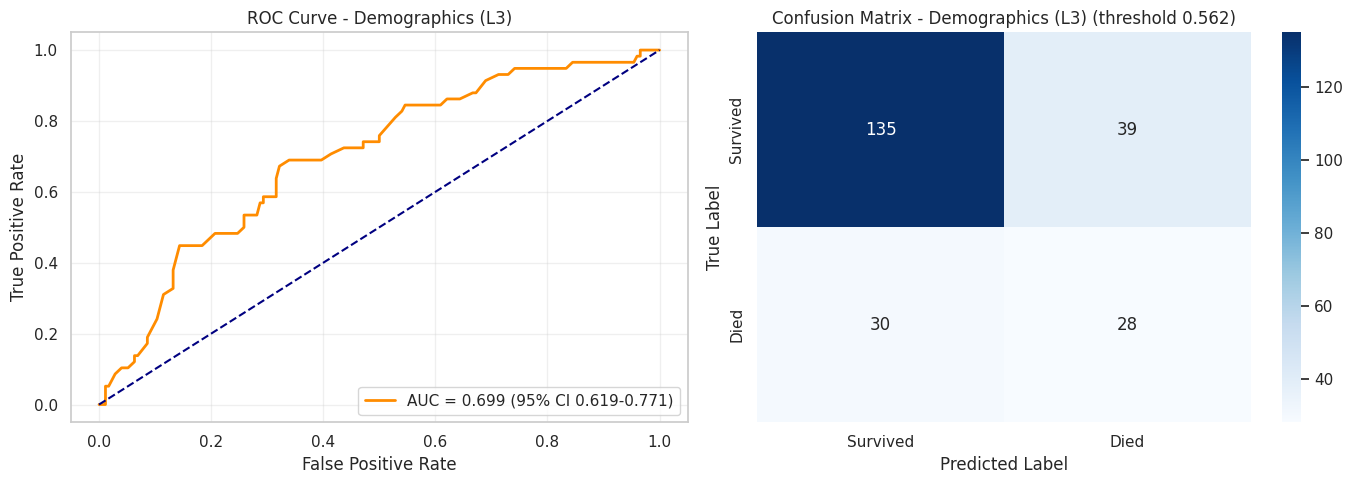


 PERFORMANCE COMPARISON (test set)


Model                       ECG: Logistic Regression ECG: Neural Network  \
Cohort Metric                                                              
L1     AUPRC                                  0.4267              0.3367   
       AUROC                                  0.5703              0.3997   
       AUROC 95% CI                      0.453-0.683         0.294-0.512   
       F1                                     0.5234              0.5294   
       NPV                                    0.7241                 0.0   
       PPV (Precision)                        0.3944                0.36   
       Sensitivity (Recall)                   0.7778                 1.0   
       Specificity                            0.3281                 0.0   
       Threshold                              0.3433              0.1946   
L2     AUPRC                                  0.4137              0.4102   
       AUROC                                  0.6065              0.5671   
       AUROC 95% CI                      0.510-0.698         0.473-0.667   
       F1                                     0.5109              0.4086   
       NPV                                    0.7705              0.7143   
       PPV (Precision)                        0.3977              0.4318   
       Sensitivity (Recall)                   0.7143              0.3878   
       Specificity                              0.47                0.75   
       Threshold                              0.0973              0.3698   
L3     AUPRC                                  0.4552              0.3271   
       AUROC                                  0.6769              0.6408   
       AUROC 95% CI                      0.597-0.764         0.567-0.721   
       F1                                      0.453                 0.4   
       NPV                                     0.844                 0.8   
       PPV (Precision)                        0.3333              0.3611   
       Sensitivity (Recall)                   0.7069              0.4483   
       Specificity                            0.5287              0.7356   
       Threshold                              0.1578               0.282   

Model                       Demographics (age+sex) Prior (chance)  
Cohort Metric                                                      
L1     AUPRC                                0.4018           0.36  
       AUROC                                0.5503            0.5  
       AUROC 95% CI                    0.434-0.675    0.500-0.500  
       F1                                   0.5169         0.5294  
       NPV                                  0.7234            0.0  
       PPV (Precision)                       0.434           0.36  
       Sensitivity (Recall)                 0.6389            1.0  
       Specificity                          0.5312            0.0  
       Threshold                            0.5238         0.3547  
L2     AUPRC                                0.4922         0.3289  
       AUROC                                0.6153            0.5  
       AUROC 95% CI                    0.505-0.715    0.500-0.500  
       F1                                    0.497         0.4949  
       NPV                                  0.7576            0.0  
       PPV (Precision)                      0.3534         0.3289  
       Sensitivity (Recall)                 0.8367            1.0  
       Specificity                            0.25            0.0  
       Threshold                            0.3981         0.3291  
L3     AUPRC                                0.4046           0.25  
       AUROC                                0.6989            0.5  
       AUROC 95% CI                    0.619-0.771    0.500-0.500  
       F1                                    0.448            0.4  
       NPV                                  0.8182            0.0  
       PPV (Precision)                      0.4179           0.25  
       Sensitivity (Recall)

In [8]:
cohorts = ['L1', 'L2', 'L3']
metric_names = ['AUROC', 'AUROC 95% CI', 'AUPRC', 'F1', 'PPV (Precision)', 'NPV',
                'Sensitivity (Recall)', 'Specificity', 'Threshold']
results_summary = []

for cohort in cohorts:
    print(f"\n{'=' * 50}\nPROCESSING COHORT: {cohort}\n{'=' * 50}")
    cohort_df = final_data_df[final_data_df['level_id'] == cohort]
    if cohort_df.empty:
        print(f"No data found for Cohort {cohort}.")
        continue

    (X_train, X_val, X_test, D_train, D_val, D_test,
     y_train, y_val, y_test) = split_cohort_data(cohort_df, embedding_cols, random_state=88)

    model_metrics = {}

    # 1. ECG embeddings: logistic regression
    lr_model = train_logistic_classifier(X_train, y_train, X_val, y_val)
    t = youden_threshold(y_val, lr_model.predict_proba(X_val)[:, 1])
    model_metrics['ECG: Logistic Regression'] = evaluate_and_plot(
        y_test, lr_model.predict_proba(X_test)[:, 1], f"ECG LR ({cohort})", t)

    # 2. ECG embeddings: neural network
    nn_model = train_nn_classifier(X_train, y_train, X_val, y_val)
    t = youden_threshold(y_val, nn_predict(nn_model, X_val))
    model_metrics['ECG: Neural Network'] = evaluate_and_plot(
        y_test, nn_predict(nn_model, X_test), f"ECG NN ({cohort})", t)

    # 3. Demographics only (age + sex): the baseline the ECG must beat
    demo_model = train_logistic_classifier(D_train, y_train, D_val, y_val)
    t = youden_threshold(y_val, demo_model.predict_proba(D_val)[:, 1])
    model_metrics['Demographics (age+sex)'] = evaluate_and_plot(
        y_test, demo_model.predict_proba(D_test)[:, 1], f"Demographics ({cohort})", t)

    # 4. Chance baseline
    dummy = DummyClassifier(strategy='prior').fit(X_train, y_train)
    model_metrics['Prior (chance)'] = evaluate_and_plot(
        y_test, dummy.predict_proba(X_test)[:, 1], f"Prior ({cohort})", threshold=y_train.mean(), plot=False)

    for model_name, m in model_metrics.items():
        for metric_name in metric_names:
            results_summary.append({'Cohort': cohort, 'Model': model_name,
                                    'Metric': metric_name, 'Value': m[metric_name]})

results_df = pd.DataFrame(results_summary)
pivot_df = results_df.pivot(index=['Cohort', 'Metric'], columns='Model', values='Value')
pivot_df = pivot_df.reindex(columns=['ECG: Logistic Regression', 'ECG: Neural Network',
                                     'Demographics (age+sex)', 'Prior (chance)'])
pivot_df.to_csv(f"{OUT_DIR}/ecg_split_results.csv")

print("\n" + "=" * 50 + "\n PERFORMANCE COMPARISON (test set)\n" + "=" * 50)
display(pivot_df)

## Optional: repeated cross-validation (more stable than the single split)
The test sets above are small (100–233 patients), so the AUROC moves a lot with the split. This section uses **every** patient once as test data (5-fold CV) and repeats with 5 seeds. It also adds *ECG + demographics* (what ECG adds on top of age/sex) and a *shuffled-label* control (should be ≈ 0.50). Easy to run on CXR too by pointing it at the CXR `final_data_df`.

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import brier_score_loss
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def cv_auc(X, y, seed, tune=True):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    clf = (LogisticRegressionCV(Cs=np.logspace(-4, 0, 8), cv=3, scoring="roc_auc", max_iter=5000)
           if tune else LogisticRegression(max_iter=5000))
    p = cross_val_predict(make_pipeline(StandardScaler(), clf), X, y, cv=skf, method="predict_proba")[:, 1]
    sb = 1 - brier_score_loss(y, p) / brier_score_loss(y, np.full_like(p, y.mean()))
    return roc_auc_score(y, p), sb

cv_rows = []
for lvl in ['L1', 'L2', 'L3']:
    d = final_data_df[final_data_df['level_id'] == lvl].dropna(subset=embedding_cols + ['age', 'sex'])
    y = d['died_1y'].astype(int).values
    X_e = d[embedding_cols].values
    X_d = np.column_stack([d['age'].astype(float).values, (d['sex'] == 'M').astype(int).values])
    for seed in range(5):
        y_shuf = np.random.default_rng(seed).permutation(y)
        for name, X, yy, tune in [("Demographics (age+sex)", X_d, y, False),
                                  ("ECG", X_e, y, True),
                                  ("ECG + demographics", np.hstack([X_e, X_d]), y, True),
                                  ("ECG, shuffled labels", X_e, y_shuf, True)]:
            auc, sb = cv_auc(X, yy, seed, tune)
            cv_rows.append({"level": lvl, "model": name, "seed": seed, "auroc": auc, "scaled_brier": sb})
        print(f"{lvl} seed {seed} done")

cv_res = pd.DataFrame(cv_rows)
cv_summary = (cv_res.groupby(["level", "model"], sort=False)
                    .agg(auroc_mean=("auroc", "mean"), auroc_min=("auroc", "min"), auroc_max=("auroc", "max"),
                         scaled_brier_mean=("scaled_brier", "mean"))
                    .round(3))
cv_summary.to_csv(f"{OUT_DIR}/ecg_cv_results.csv")
cv_summary

L1 seed 0 done
L1 seed 1 done
L1 seed 2 done
L1 seed 3 done
L1 seed 4 done
L2 seed 0 done
L2 seed 1 done
L2 seed 2 done
L2 seed 3 done
L2 seed 4 done
L3 seed 0 done
L3 seed 1 done
L3 seed 2 done
L3 seed 3 done
L3 seed 4 done


auroc_mean  auroc_min  auroc_max  \
level model                                                      
L1    Demographics (age+sex)       0.648      0.646      0.650   
      ECG                          0.557      0.548      0.566   
      ECG + demographics           0.630      0.623      0.635   
      ECG, shuffled labels         0.506      0.468      0.547   
L2    Demographics (age+sex)       0.641      0.638      0.643   
      ECG                          0.595      0.577      0.605   
      ECG + demographics           0.657      0.651      0.664   
      ECG, shuffled labels         0.504      0.491      0.524   
L3    Demographics (age+sex)       0.660      0.660      0.661   
      ECG                          0.635      0.624      0.643   
      ECG + demographics           0.693      0.685      0.702   
      ECG, shuffled labels         0.505      0.472      0.525   

                              scaled_brier_mean  
level model                                      
L1    Demographics (age+sex)              0.060  
      ECG                                -0.057  
      ECG + demographics                  0.026  
      ECG, shuffled labels               -0.081  
L2    Demographics (age+sex)              0.053  
      ECG                                -0.042  
      ECG + demographics                  0.048  
      ECG, shuffled labels               -0.077  
L3    Demographics (age+sex)              0.062  
      ECG                                 0.020  
      ECG + demographics                  0.083  
      ECG, shuffled labels               -0.086

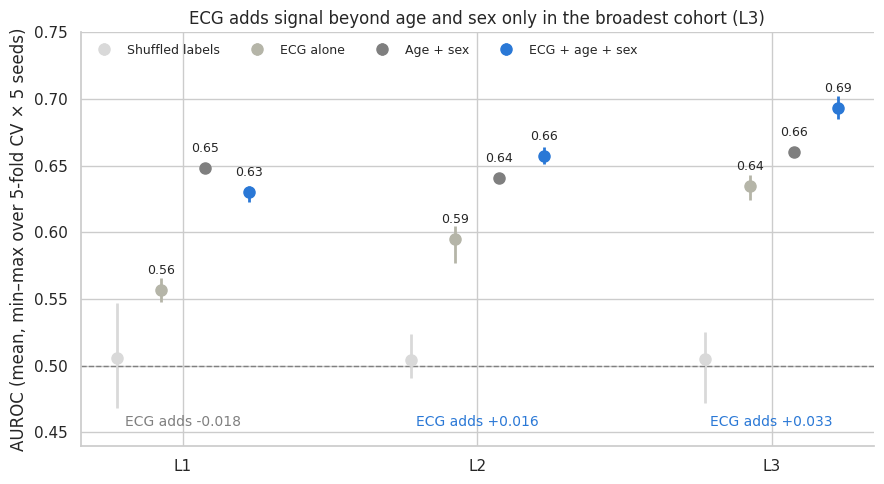

In [10]:
import matplotlib.pyplot as plt

order  = ["ECG, shuffled labels", "ECG", "Demographics (age+sex)", "ECG + demographics"]
labels = ["Shuffled labels", "ECG alone", "Age + sex", "ECG + age + sex"]
colors = ["#d9d9d9", "#b5b5a8", "#7f7f7f", "#2a78d6"]
levels = ["L1", "L2", "L3"]

s = cv_summary.reset_index()
fig, ax = plt.subplots(figsize=(9, 5))
for j, (m, lab, c) in enumerate(zip(order, labels, colors)):
    d = s[s["model"] == m].set_index("level").loc[levels]
    x = [i + (j - 1.5) * 0.15 for i in range(len(levels))]
    ax.errorbar(x, d["auroc_mean"],
                yerr=[d["auroc_mean"] - d["auroc_min"], d["auroc_max"] - d["auroc_mean"]],
                fmt="o", color=c, ms=8, capsize=0, lw=2, label=lab)
    if m != "ECG, shuffled labels":
        for xi, v in zip(x, d["auroc_mean"]):
            ax.text(xi, v + 0.012, f"{v:.2f}", ha="center", fontsize=9)

# ECG 带来的提升 = (ECG + demographics) - (Demographics)
for i, lv in enumerate(levels):
    g = s[(s.level == lv) & (s.model == "ECG + demographics")].auroc_mean.item() \
      - s[(s.level == lv) & (s.model == "Demographics (age+sex)")].auroc_mean.item()
    ax.text(i, 0.455, f"ECG adds {g:+.3f}", ha="center", fontsize=10,
            color="#2a78d6" if g > 0 else "grey")

ax.axhline(0.5, ls="--", color="grey", lw=1)
ax.set_xticks(range(len(levels)), levels)
ax.set_ylim(0.44, 0.75)
ax.set_ylabel("AUROC (mean, min–max over 5-fold CV × 5 seeds)")
ax.set_title("ECG adds signal beyond age and sex only in the broadest cohort (L3)")
ax.legend(ncol=4, loc="upper left", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ecg_cv_auroc.png", dpi=200)
plt.show()